In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
df = yf.download("RELIANCE.NS",start="2020-01-01",end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
df.shape

(992, 5)

In [6]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,675.324219,683.152914,673.490123,679.081997,14004468
2020-01-02,686.821228,689.348791,676.397899,676.397899,17710316
2020-01-03,687.648865,689.661956,681.318790,685.792313,20984698
2020-01-06,671.700684,683.510767,670.134933,679.976719,24519177
2020-01-07,682.034546,686.463335,677.068889,679.529321,16683622


In [7]:
df.columns = ['Close','High','Low','Open','Volume']
df.index.name = 'Date'
df.head(4)

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,675.324219,683.152914,673.490123,679.081997,14004468
2020-01-02,686.821228,689.348791,676.397899,676.397899,17710316
2020-01-03,687.648865,689.661956,681.318790,685.792313,20984698
2020-01-06,671.700684,683.510767,670.134933,679.976719,24519177


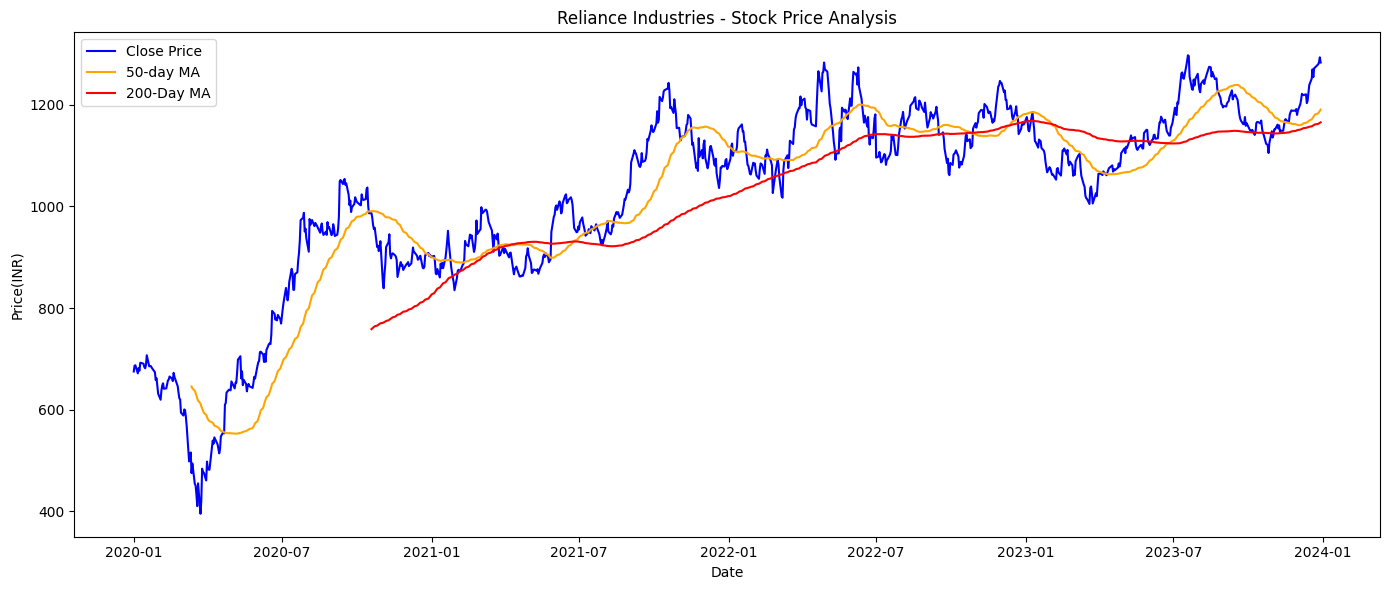

In [9]:
# basic stats
df.describe()

# daliy return 
df['Daily_Return'] = df['Close'].pct_change()*100

# 50 day & 200-day moving average
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'],label = 'Close Price',color = 'blue')
plt.plot(df['MA50'],label = '50-day MA',color='orange')
plt.plot(df['MA200'],label = '200-Day MA',color ='red')
plt.title('Reliance Industries - Stock Price Analysis')
plt.xlabel('Date')
plt.ylabel('Price(INR)')
plt.legend()
plt.tight_layout()
plt.show()

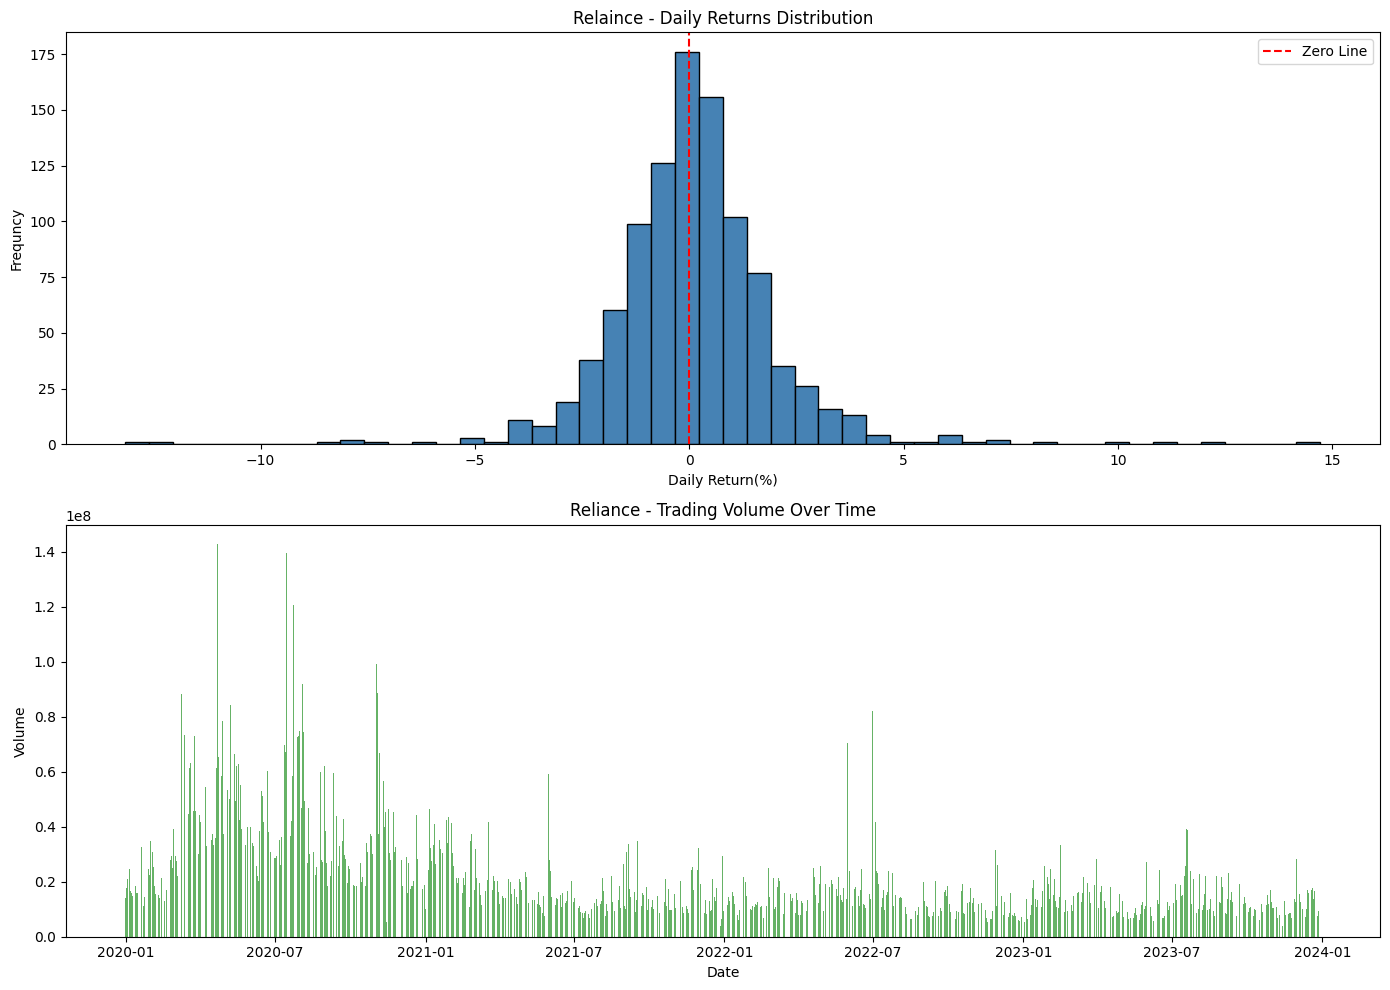

In [11]:
fig,axes = plt.subplots(2,1,figsize =(14,10))
axes[0].hist(df['Daily_Return'].dropna(),bins =50,color='steelblue',edgecolor = 'black')
axes[0].set_title('Relaince - Daily Returns Distribution')
axes[0].set_xlabel('Daily Return(%)')
axes[0].set_ylabel('Frequncy')
axes[0].axvline(0,color='red',linestyle='--',label = 'Zero Line')
axes[0].legend()

axes[1].bar(df.index,df['Volume'],color = 'green',alpha=0.6)
axes[1].set_title('Reliance - Trading Volume Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume')
plt.tight_layout()
plt.show()